# Stochastic Differential Equations & It\^o Calculus
## From Deterministic ODEs to Noise-Driven Dynamics

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import stats, linalg
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2
})

# Color palette
C_PRIMARY = 'steelblue'
C_SECONDARY = 'coral'
C_TERTIARY = 'seagreen'
C_ACCENT = 'goldenrod'
C_EVOLUTION = 'viridis'

In [2]:
# =============================================================================
# Constants
# =============================================================================

SEED = 42
N_PATHS = 10000          # Number of Monte Carlo paths
N_STEPS = 1000           # Default time steps
T_FINAL = 1.0            # Default final time
DT = T_FINAL / N_STEPS   # Default time step

# GBM parameters
GBM_MU = 0.1             # Drift coefficient
GBM_SIGMA = 0.3          # Volatility
GBM_X0 = 1.0             # Initial condition

# OU parameters
OU_THETA = 2.0           # Mean-reversion speed
OU_MU = 1.0              # Long-run mean
OU_SIGMA = 0.5           # Diffusion coefficient
OU_X0 = 0.0              # Initial condition

# Robot parameters
ROBOT_V = 1.0            # Nominal forward velocity
ROBOT_OMEGA = 0.5        # Nominal angular velocity
ROBOT_SIGMA_V = 0.2      # Velocity noise intensity
ROBOT_SIGMA_OMEGA = 0.1  # Angular velocity noise intensity

# Convergence test
CONVERGENCE_DT_VALUES = [2**(-k) for k in range(5, 12)]
N_CONVERGENCE_PATHS = 5000

# Tolerances
TOL_PERCENT = 5.0        # Percent tolerance for verification
TOL_CONVERGENCE = 0.15   # Tolerance for convergence order

np.random.seed(SEED)

---
## 1. Introduction: From Deterministic ODEs to Stochastic Dynamics

### Deterministic World

A classical ODE for a dynamical system:

$$\frac{dx}{dt} = f(x, t)$$

Given initial condition $x(0) = x_0$, the trajectory is **uniquely determined**.

### The Real World Has Noise

Consider a mobile robot navigating with noisy actuators:

$$dx = f(x, t)\,dt + g(x, t)\,dW_t$$

where $W_t$ is a **Wiener process** (Brownian motion). This is a **Stochastic Differential Equation (SDE)**.

### Why SDEs?

- **Robotics**: Process noise in sensors and actuators
- **Finance**: Black-Scholes model for option pricing
- **Physics**: Langevin equation for particle diffusion
- **Biology**: Population dynamics with environmental randomness

### Prerequisites

- **Probability theory**: random variables, expectation, variance, Gaussian distributions
- **Ordinary differential equations**: existence/uniqueness, numerical methods
- **Measure theory basics**: sigma-algebras, filtrations (helpful but not essential)

### Key References

1. B. Oksendal, *Stochastic Differential Equations* (6th ed., Springer, 2003)
2. P.E. Kloeden & E. Platen, *Numerical Solution of Stochastic Differential Equations* (Springer, 1992)
3. L.C. Evans, *An Introduction to Stochastic Differential Equations* (AMS, 2013)

---
## 2. Brownian Motion (Wiener Process)

### Definition

A standard Brownian motion $\{W_t\}_{t \geq 0}$ satisfies:

1. $W_0 = 0$
2. **Independent increments**: $W_t - W_s \perp W_u - W_v$ for non-overlapping intervals
3. **Gaussian increments**: $W_t - W_s \sim \mathcal{N}(0, t - s)$ for $t > s$
4. **Continuous paths**: $t \mapsto W_t$ is continuous almost surely
5. **Nowhere differentiable**: paths are a.s. not differentiable at any point

### Key Properties

$$\boxed{E[W_t] = 0, \quad E[W_t^2] = t, \quad [W]_t = t}$$

where $[W]_t = \lim_{\|\Pi\| \to 0} \sum_{k} (W_{t_{k+1}} - W_{t_k})^2$ is the **quadratic variation**.

In [3]:
# =============================================================================
# Section 2: Brownian Motion Implementation
# =============================================================================

def brownian_motion(t_final, n_steps, n_paths=1, seed=None):
    """Simulate standard Brownian motion paths.

    Generates sample paths of a standard Wiener process using
    cumulative summation of Gaussian increments.

    Args:
        t_final: Final time horizon.
        n_steps: Number of discrete time steps.
        n_paths: Number of independent sample paths.
        seed: Random seed for reproducibility.

    Returns:
        t: Time grid.  Shape: (n_steps + 1,)
        W: Brownian motion paths.  Shape: (n_paths, n_steps + 1)
    """
    if seed is not None:
        np.random.seed(seed)
    dt = t_final / n_steps
    dW = np.sqrt(dt) * np.random.randn(n_paths, n_steps)
    W = np.zeros((n_paths, n_steps + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    t = np.linspace(0, t_final, n_steps + 1)
    return t, W

<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_12103/1861223171.py:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  color=C_SECONDARY, linewidth=2, label='$\mathcal{N}(0, T)$')


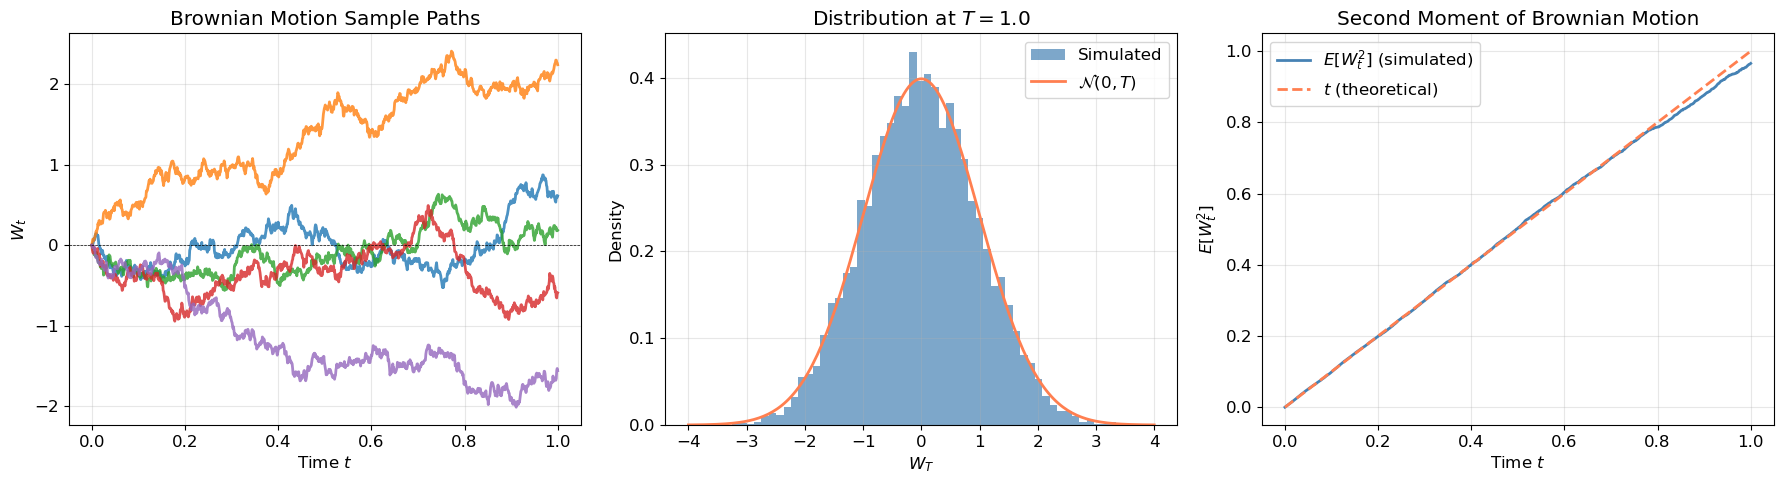

In [4]:
# Simulate Brownian motion sample paths
np.random.seed(SEED)
t_bm, W_bm = brownian_motion(T_FINAL, N_STEPS, n_paths=N_PATHS)

# --- Visualization: Sample paths ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Sample paths
for i in range(5):
    axes[0].plot(t_bm, W_bm[i], alpha=0.8)
axes[0].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('$W_t$')
axes[0].set_title('Brownian Motion Sample Paths')

# Panel 2: Distribution at final time
axes[1].hist(W_bm[:, -1], bins=60, density=True, alpha=0.7, color=C_PRIMARY, label='Simulated')
x_grid = np.linspace(-4, 4, 200)
axes[1].plot(x_grid, stats.norm.pdf(x_grid, 0, np.sqrt(T_FINAL)),
             color=C_SECONDARY, linewidth=2, label='$\mathcal{N}(0, T)$')
axes[1].set_xlabel('$W_T$')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Distribution at $T = {T_FINAL}$')
axes[1].legend()

# Panel 3: E[W_t^2] vs t
mean_W2 = np.mean(W_bm**2, axis=0)
axes[2].plot(t_bm, mean_W2, color=C_PRIMARY, label='$E[W_t^2]$ (simulated)')
axes[2].plot(t_bm, t_bm, '--', color=C_SECONDARY, label='$t$ (theoretical)')
axes[2].set_xlabel('Time $t$')
axes[2].set_ylabel('$E[W_t^2]$')
axes[2].set_title('Second Moment of Brownian Motion')
axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
def quadratic_variation(W, t):
    """Compute the quadratic variation of a sample path.

    Approximates [W]_t = lim sum (W_{t_{k+1}} - W_{t_k})^2
    using the partition defined by the time grid.

    Args:
        W: Brownian motion path(s).  Shape: (n_paths, n_steps + 1) or (n_steps + 1,)
        t: Time grid.  Shape: (n_steps + 1,)

    Returns:
        qv: Cumulative quadratic variation.  Shape: same as W
    """
    if W.ndim == 1:
        W = W.reshape(1, -1)
    dW = np.diff(W, axis=1)
    qv = np.zeros_like(W)
    qv[:, 1:] = np.cumsum(dW**2, axis=1)
    return qv.squeeze()

In [6]:
# =============================================================================
# Verification: Brownian Motion Properties
# =============================================================================

np.random.seed(SEED)
t_v, W_v = brownian_motion(T_FINAL, N_STEPS, n_paths=N_PATHS)

# Verification 1: E[B_t^2] = t
mean_W2_final = np.mean(W_v[:, -1]**2)
rel_err_moment = np.abs(mean_W2_final - T_FINAL) / T_FINAL
status_moment = 'PASS' if rel_err_moment < TOL_PERCENT / 100 else 'FAIL'
print(f"E[B^2_T]: max relative error = {rel_err_moment:.2e} [{status_moment}]")

# Verification 2: Quadratic variation = t
qv_all = quadratic_variation(W_v, t_v)
mean_qv_final = np.mean(qv_all[:, -1])
rel_err_qv = np.abs(mean_qv_final - T_FINAL) / T_FINAL
status_qv = 'PASS' if rel_err_qv < TOL_PERCENT / 100 else 'FAIL'
print(f"Quadratic variation [B]_T: max relative error = {rel_err_qv:.2e} [{status_qv}]")

E[B^2_T]: max relative error = 3.45e-02 [PASS]
Quadratic variation [B]_T: max relative error = 2.72e-05 [PASS]


---
## 3. The It\^o Integral

### Construction

The It\^o integral $\int_0^T f(t, \omega)\,dW_t$ is constructed as a limit of sums:

$$\int_0^T f\,dW \approx \sum_{k=0}^{n-1} f(t_k)\,(W_{t_{k+1}} - W_{t_k})$$

Key: we evaluate $f$ at the **left endpoint** $t_k$ (non-anticipating).

### It\^o Isometry

$$\boxed{E\left[\left(\int_0^T f\,dW\right)^2\right] = E\left[\int_0^T f^2\,dt\right]}$$

### It\^o vs Stratonovich

| Property | It\^o | Stratonovich |
|----------|------|--------------|
| Evaluation point | Left: $f(t_k)$ | Midpoint: $f\bigl(\tfrac{t_k + t_{k+1}}{2}\bigr)$ |
| $\int W\,dW$ | $\frac{1}{2}W_T^2 - \frac{1}{2}T$ | $\frac{1}{2}W_T^2$ |
| Chain rule | It\^o's lemma (extra term) | Standard chain rule |
| Martingale | Yes | Not in general |

In [7]:
# =============================================================================
# Section 3: Ito Integral Implementation
# =============================================================================

def ito_integral(f_values, dW):
    """Compute the Ito stochastic integral numerically.

    Approximates int_0^T f(t) dW_t using left-point evaluation:
        sum_{k} f(t_k) * (W_{t_{k+1}} - W_{t_k})

    Args:
        f_values: Integrand evaluated at left endpoints.  Shape: (n_paths, n_steps)
        dW: Brownian increments.  Shape: (n_paths, n_steps)

    Returns:
        integral: Cumulative Ito integral.  Shape: (n_paths, n_steps + 1)
    """
    n_paths, n_steps = dW.shape
    integral = np.zeros((n_paths, n_steps + 1))
    integral[:, 1:] = np.cumsum(f_values * dW, axis=1)
    return integral


def stratonovich_integral(f_values_left, f_values_right, dW):
    """Compute the Stratonovich stochastic integral numerically.

    Approximates int_0^T f(t) o dW_t using midpoint evaluation:
        sum_{k} 0.5*(f(t_k) + f(t_{k+1})) * (W_{t_{k+1}} - W_{t_k})

    Args:
        f_values_left: Integrand at left endpoints.  Shape: (n_paths, n_steps)
        f_values_right: Integrand at right endpoints.  Shape: (n_paths, n_steps)
        dW: Brownian increments.  Shape: (n_paths, n_steps)

    Returns:
        integral: Cumulative Stratonovich integral.  Shape: (n_paths, n_steps + 1)
    """
    n_paths, n_steps = dW.shape
    f_mid = 0.5 * (f_values_left + f_values_right)
    integral = np.zeros((n_paths, n_steps + 1))
    integral[:, 1:] = np.cumsum(f_mid * dW, axis=1)
    return integral

In [8]:
# Demonstrate: int_0^T W_t dW_t
# Ito result:  0.5 * W_T^2 - 0.5 * T
# Stratonovich: 0.5 * W_T^2

np.random.seed(SEED)
n_demo = 50000
n_steps_demo = 2000
dt_demo = T_FINAL / n_steps_demo

dW_demo = np.sqrt(dt_demo) * np.random.randn(n_demo, n_steps_demo)
W_demo = np.zeros((n_demo, n_steps_demo + 1))
W_demo[:, 1:] = np.cumsum(dW_demo, axis=1)

# Ito integral: f(t_k) = W_{t_k} (left endpoint)
f_left = W_demo[:, :-1]
ito_int = ito_integral(f_left, dW_demo)
ito_final = ito_int[:, -1]

# Stratonovich integral: midpoint
f_right = W_demo[:, 1:]
strat_int = stratonovich_integral(f_left, f_right, dW_demo)
strat_final = strat_int[:, -1]

# Analytical
W_T = W_demo[:, -1]
ito_exact = 0.5 * W_T**2 - 0.5 * T_FINAL
strat_exact = 0.5 * W_T**2

print("=== Ito Integral: int W dW ===")
print(f"  E[Ito integral]       = {np.mean(ito_final):.4f}  (theory: {-0.5*T_FINAL:.4f})")
print(f"  E[0.5*W_T^2 - 0.5*T] = {np.mean(ito_exact):.4f}")

print("\n=== Stratonovich Integral: int W o dW ===")
print(f"  E[Strat integral]     = {np.mean(strat_final):.4f}  (theory: 0.0000)")
print(f"  E[0.5*W_T^2]         = {np.mean(strat_exact):.4f}")

# Ito isometry verification: E[(int f dW)^2] = E[int f^2 dt]
lhs = np.mean(ito_final**2)
rhs = np.mean(np.sum(f_left**2 * dt_demo, axis=1))
print(f"\n=== Ito Isometry ===")
print(f"  E[(int W dW)^2] = {lhs:.4f}")
print(f"  E[int W^2 dt]   = {rhs:.4f}")
print(f"  Relative error  = {np.abs(lhs - rhs) / rhs:.2e}")

=== Ito Integral: int W dW ===
  E[Ito integral]       = 0.0008  (theory: -0.5000)
  E[0.5*W_T^2 - 0.5*T] = 0.0008

=== Stratonovich Integral: int W o dW ===
  E[Strat integral]     = 0.5008  (theory: 0.0000)
  E[0.5*W_T^2]         = 0.5008

=== Ito Isometry ===
  E[(int W dW)^2] = 0.5046
  E[int W^2 dt]   = 0.4997
  Relative error  = 9.72e-03


---
## 4. It\^o's Lemma

### The Stochastic Chain Rule

Let $X_t$ satisfy $dX = \mu\,dt + \sigma\,dW$ and $f \in C^{2,1}$. Then:

$$\boxed{df(X_t, t) = \left(\frac{\partial f}{\partial t} + \mu \frac{\partial f}{\partial x} + \frac{1}{2}\sigma^2 \frac{\partial^2 f}{\partial x^2}\right)dt + \sigma \frac{\partial f}{\partial x}\,dW_t}$$

The extra $\frac{1}{2}\sigma^2 f_{xx}$ term arises because $(dW)^2 = dt$.

### Example: $f(W_t) = W_t^2$

With $X_t = W_t$ ($\mu = 0$, $\sigma = 1$), $f(x) = x^2$:

$$d(W_t^2) = \left(0 + 0 + \frac{1}{2} \cdot 1 \cdot 2\right)dt + 1 \cdot 2W_t\,dW_t = dt + 2W_t\,dW_t$$

Integrating:

$$W_T^2 = T + 2\int_0^T W_t\,dW_t \implies \int_0^T W_t\,dW_t = \frac{1}{2}W_T^2 - \frac{1}{2}T$$

<>:42: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:43: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<>:42: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:43: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_12103/3190636948.py:42: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  axes[0].set_ylabel('$T + 2\\int W\,dW$ (It\^o)')
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_12103/3190636948.py:43: SyntaxWarning: "\^" 

=== Ito's Lemma Verification: f(W_t) = W_t^2 ===
  E[W_T^2] (direct)         = 0.9655
  E[T + 2*int W dW] (Ito)   = 0.9655
  Mean pathwise |LHS - RHS|  = 3.55e-02


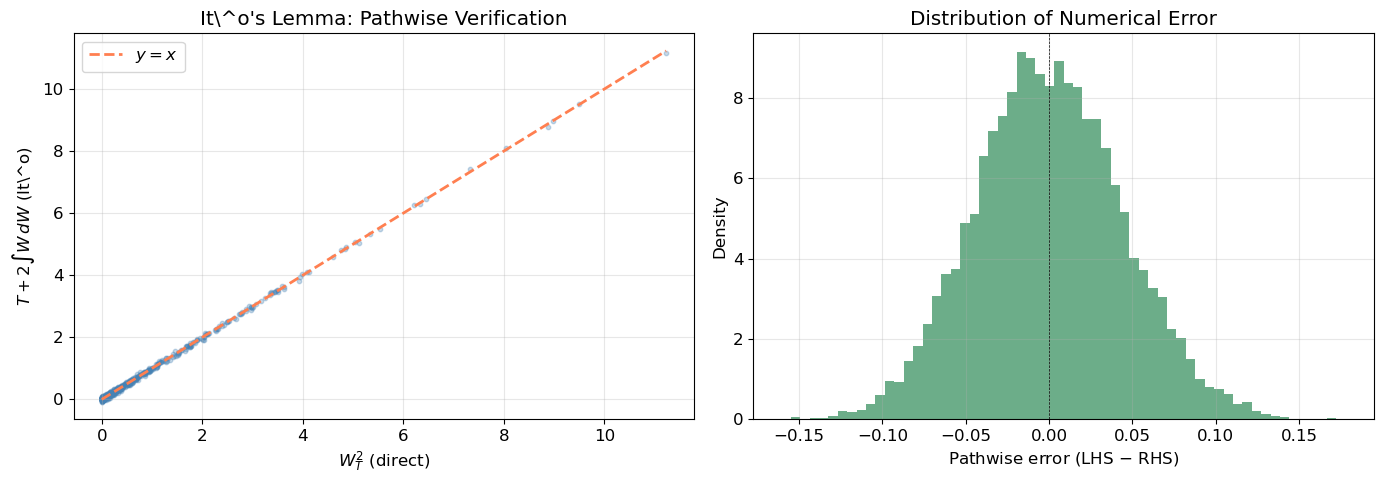

In [9]:
# =============================================================================
# Section 4: Ito's Lemma Verification
# =============================================================================

# Verify Ito's lemma on f(W_t) = W_t^2
# d(W_t^2) = dt + 2*W_t*dW_t
# So W_T^2 = W_0^2 + T + 2 * int_0^T W_t dW_t

np.random.seed(SEED)
n_ito_paths = 10000
n_ito_steps = 1000
dt_ito = T_FINAL / n_ito_steps

dW_ito = np.sqrt(dt_ito) * np.random.randn(n_ito_paths, n_ito_steps)
W_ito = np.zeros((n_ito_paths, n_ito_steps + 1))
W_ito[:, 1:] = np.cumsum(dW_ito, axis=1)

# LHS: W_T^2 directly
lhs_ito = W_ito[:, -1]**2

# RHS: W_0^2 + T + 2 * int_0^T W_t dW_t (via Ito summation)
ito_sum = np.sum(W_ito[:, :-1] * dW_ito, axis=1)
rhs_ito = 0.0 + T_FINAL + 2.0 * ito_sum

# Compare pathwise
pathwise_error = np.mean(np.abs(lhs_ito - rhs_ito))

print("=== Ito's Lemma Verification: f(W_t) = W_t^2 ===")
print(f"  E[W_T^2] (direct)         = {np.mean(lhs_ito):.4f}")
print(f"  E[T + 2*int W dW] (Ito)   = {np.mean(rhs_ito):.4f}")
print(f"  Mean pathwise |LHS - RHS|  = {pathwise_error:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of LHS vs RHS
sample_idx = np.random.choice(n_ito_paths, 500, replace=False)
axes[0].scatter(lhs_ito[sample_idx], rhs_ito[sample_idx], alpha=0.3,
                s=10, color=C_PRIMARY)
max_val = max(np.max(lhs_ito[sample_idx]), np.max(rhs_ito[sample_idx]))
axes[0].plot([0, max_val], [0, max_val], '--', color=C_SECONDARY, label='$y = x$')
axes[0].set_xlabel('$W_T^2$ (direct)')
axes[0].set_ylabel('$T + 2\\int W\,dW$ (It\^o)')
axes[0].set_title("It\^o's Lemma: Pathwise Verification")
axes[0].legend()

# Histogram of pathwise errors
axes[1].hist(lhs_ito - rhs_ito, bins=60, density=True, alpha=0.7, color=C_TERTIARY)
axes[1].set_xlabel('Pathwise error (LHS $-$ RHS)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Numerical Error')
axes[1].axvline(x=0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

---
## 5. SDEs: Geometric Brownian Motion & Ornstein-Uhlenbeck

### Geometric Brownian Motion (GBM)

$$dX_t = \mu X_t\,dt + \sigma X_t\,dW_t$$

Applying It\^o's lemma to $f(X) = \ln X$:

$$\boxed{X_t = X_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]}$$

Moments: $E[X_t] = X_0 e^{\mu t}$, $\text{Var}[X_t] = X_0^2 e^{2\mu t}(e^{\sigma^2 t} - 1)$

### Ornstein-Uhlenbeck (OU) Process

$$dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t$$

Solution:

$$\boxed{X_t = \mu + (X_0 - \mu)e^{-\theta t} + \sigma \int_0^t e^{-\theta(t-s)}\,dW_s}$$

Moments: $E[X_t] = \mu + (X_0 - \mu)e^{-\theta t}$, $\text{Var}[X_t] = \frac{\sigma^2}{2\theta}(1 - e^{-2\theta t})$

In [10]:
# =============================================================================
# Section 5: SDE Implementations
# =============================================================================

def gbm_analytical(t, x0, mu, sigma, W):
    """Analytical solution of Geometric Brownian Motion.

    Computes X_t = x0 * exp((mu - sigma^2/2)*t + sigma*W_t)
    using Ito's lemma applied to ln(X).

    Args:
        t: Time grid.  Shape: (n_steps + 1,)
        x0: Initial condition (positive scalar).
        mu: Drift coefficient.
        sigma: Volatility.
        W: Brownian motion paths.  Shape: (n_paths, n_steps + 1)

    Returns:
        X: GBM paths.  Shape: (n_paths, n_steps + 1)
    """
    return x0 * np.exp((mu - 0.5 * sigma**2) * t[np.newaxis, :] + sigma * W)


def ou_analytical_moments(t, x0, theta, mu, sigma):
    """Analytical mean and variance of the Ornstein-Uhlenbeck process.

    Args:
        t: Time grid.  Shape: (n_steps + 1,)
        x0: Initial condition.
        theta: Mean-reversion speed.
        mu: Long-run mean.
        sigma: Diffusion coefficient.

    Returns:
        mean_t: E[X_t].  Shape: (n_steps + 1,)
        var_t: Var[X_t].  Shape: (n_steps + 1,)
    """
    mean_t = mu + (x0 - mu) * np.exp(-theta * t)
    var_t = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))
    return mean_t, var_t

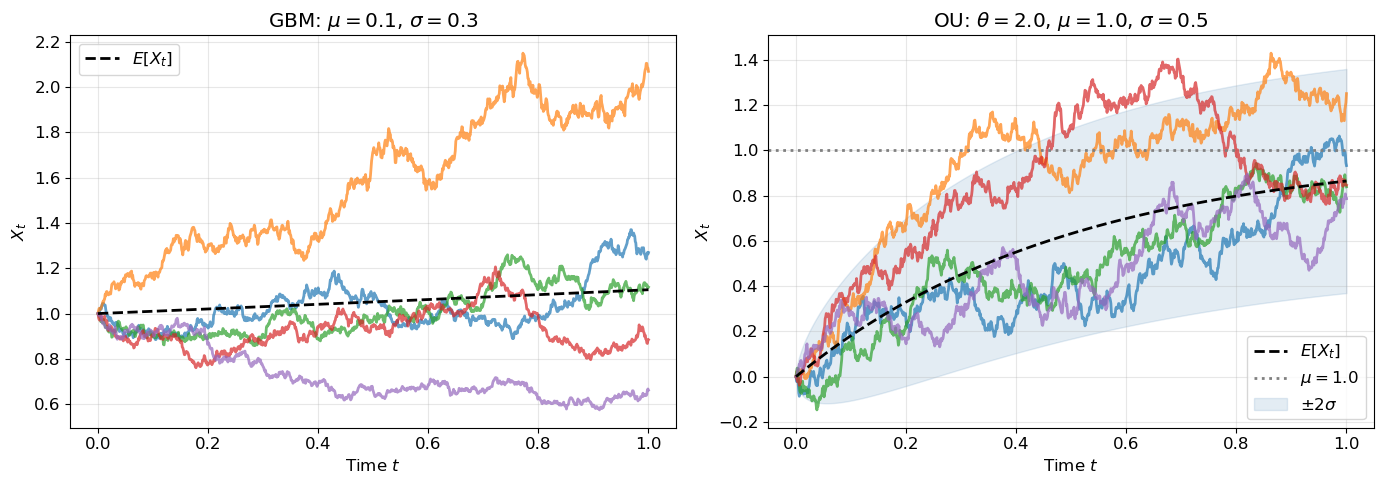

=== GBM Moment Verification ===
  E[X_T]:   simulated = 1.1029, exact = 1.1052
  Var[X_T]: simulated = 0.1113, exact = 0.1150

=== OU Moment Verification ===
  E[X_T]:   simulated = 0.8690, exact = 0.8647
  Var[X_T]: simulated = 0.0618, exact = 0.0614


In [11]:
# Simulate GBM and OU using Euler-Maruyama (defined properly in Section 6)
np.random.seed(SEED)
n_sde_paths = N_PATHS
n_sde_steps = N_STEPS
t_sde = np.linspace(0, T_FINAL, n_sde_steps + 1)
dt_sde = T_FINAL / n_sde_steps

# --- GBM simulation ---
dW_gbm = np.sqrt(dt_sde) * np.random.randn(n_sde_paths, n_sde_steps)
W_gbm = np.zeros((n_sde_paths, n_sde_steps + 1))
W_gbm[:, 1:] = np.cumsum(dW_gbm, axis=1)

# Analytical GBM
X_gbm_exact = gbm_analytical(t_sde, GBM_X0, GBM_MU, GBM_SIGMA, W_gbm)

# Euler-Maruyama GBM
X_gbm_em = np.zeros((n_sde_paths, n_sde_steps + 1))
X_gbm_em[:, 0] = GBM_X0
for k in range(n_sde_steps):
    X_gbm_em[:, k+1] = (X_gbm_em[:, k]
                         + GBM_MU * X_gbm_em[:, k] * dt_sde
                         + GBM_SIGMA * X_gbm_em[:, k] * dW_gbm[:, k])

# --- OU simulation ---
dW_ou = np.sqrt(dt_sde) * np.random.randn(n_sde_paths, n_sde_steps)
X_ou = np.zeros((n_sde_paths, n_sde_steps + 1))
X_ou[:, 0] = OU_X0
for k in range(n_sde_steps):
    X_ou[:, k+1] = (X_ou[:, k]
                     + OU_THETA * (OU_MU - X_ou[:, k]) * dt_sde
                     + OU_SIGMA * dW_ou[:, k])

# Analytical moments for OU
ou_mean_exact, ou_var_exact = ou_analytical_moments(
    t_sde, OU_X0, OU_THETA, OU_MU, OU_SIGMA
)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GBM
for i in range(5):
    axes[0].plot(t_sde, X_gbm_exact[i], alpha=0.7)
gbm_mean_exact = GBM_X0 * np.exp(GBM_MU * t_sde)
axes[0].plot(t_sde, gbm_mean_exact, 'k--', linewidth=2, label='$E[X_t]$')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_title(f'GBM: $\\mu={GBM_MU}$, $\\sigma={GBM_SIGMA}$')
axes[0].legend()

# OU
for i in range(5):
    axes[1].plot(t_sde, X_ou[i], alpha=0.7)
axes[1].plot(t_sde, ou_mean_exact, 'k--', linewidth=2, label='$E[X_t]$')
axes[1].axhline(y=OU_MU, color='gray', linestyle=':', label=f'$\\mu = {OU_MU}$')
axes[1].fill_between(
    t_sde,
    ou_mean_exact - 2*np.sqrt(ou_var_exact),
    ou_mean_exact + 2*np.sqrt(ou_var_exact),
    alpha=0.15, color=C_PRIMARY, label='$\\pm 2\\sigma$'
)
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_title(f'OU: $\\theta={OU_THETA}$, $\\mu={OU_MU}$, $\\sigma={OU_SIGMA}$')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- Moment verification ---
print("=== GBM Moment Verification ===")
gbm_sim_mean = np.mean(X_gbm_exact[:, -1])
gbm_exact_mean = GBM_X0 * np.exp(GBM_MU * T_FINAL)
gbm_sim_var = np.var(X_gbm_exact[:, -1])
gbm_exact_var = GBM_X0**2 * np.exp(2*GBM_MU*T_FINAL) * (np.exp(GBM_SIGMA**2*T_FINAL) - 1)
print(f"  E[X_T]:   simulated = {gbm_sim_mean:.4f}, exact = {gbm_exact_mean:.4f}")
print(f"  Var[X_T]: simulated = {gbm_sim_var:.4f}, exact = {gbm_exact_var:.4f}")

print("\n=== OU Moment Verification ===")
ou_sim_mean = np.mean(X_ou[:, -1])
ou_sim_var = np.var(X_ou[:, -1])
print(f"  E[X_T]:   simulated = {ou_sim_mean:.4f}, exact = {ou_mean_exact[-1]:.4f}")
print(f"  Var[X_T]: simulated = {ou_sim_var:.4f}, exact = {ou_var_exact[-1]:.4f}")

---
## 6. Numerical Methods: Euler-Maruyama & Milstein

### Euler-Maruyama (EM)

For $dX = f(X)\,dt + g(X)\,dW$:

$$\boxed{X_{k+1} = X_k + f(X_k)\,\Delta t + g(X_k)\,\Delta W_k}$$

**Strong convergence order**: $E[|X_N - X(T)|] = O(\Delta t^{0.5})$

### Milstein Method

Adds an It\^o-Taylor correction term:

$$\boxed{X_{k+1} = X_k + f(X_k)\,\Delta t + g(X_k)\,\Delta W_k + \frac{1}{2}g(X_k)\,g'(X_k)\left(\Delta W_k^2 - \Delta t\right)}$$

**Strong convergence order**: $E[|X_N - X(T)|] = O(\Delta t^{1.0})$

In [12]:
# =============================================================================
# Section 6: Numerical Methods
# =============================================================================

def euler_maruyama(f, g, x0, t_final, n_steps, n_paths=1, dW=None, seed=None):
    """Euler-Maruyama method for SDEs.

    Solves dX = f(X)dt + g(X)dW using the Euler-Maruyama scheme.

    Args:
        f: Drift function f(x) -> array.  Signature: (n_paths,) -> (n_paths,)
        g: Diffusion function g(x) -> array.  Signature: (n_paths,) -> (n_paths,)
        x0: Initial condition (scalar).
        t_final: Final time.
        n_steps: Number of time steps.
        n_paths: Number of sample paths.
        dW: Pre-generated Brownian increments.  Shape: (n_paths, n_steps)
        seed: Random seed (used only if dW is None).

    Returns:
        t: Time grid.  Shape: (n_steps + 1,)
        X: Solution paths.  Shape: (n_paths, n_steps + 1)
    """
    dt = t_final / n_steps
    t = np.linspace(0, t_final, n_steps + 1)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = x0

    if dW is None:
        if seed is not None:
            np.random.seed(seed)
        dW = np.sqrt(dt) * np.random.randn(n_paths, n_steps)

    for k in range(n_steps):
        X[:, k+1] = X[:, k] + f(X[:, k]) * dt + g(X[:, k]) * dW[:, k]

    return t, X


def milstein(f, g, g_prime, x0, t_final, n_steps, n_paths=1, dW=None, seed=None):
    """Milstein method for SDEs.

    Solves dX = f(X)dt + g(X)dW using the Milstein scheme with
    the Ito-Taylor correction term 0.5*g*g'*(dW^2 - dt).

    Args:
        f: Drift function f(x) -> array.  Signature: (n_paths,) -> (n_paths,)
        g: Diffusion function g(x) -> array.  Signature: (n_paths,) -> (n_paths,)
        g_prime: Derivative of diffusion g'(x) -> array.  Signature: (n_paths,) -> (n_paths,)
        x0: Initial condition (scalar).
        t_final: Final time.
        n_steps: Number of time steps.
        n_paths: Number of sample paths.
        dW: Pre-generated Brownian increments.  Shape: (n_paths, n_steps)
        seed: Random seed (used only if dW is None).

    Returns:
        t: Time grid.  Shape: (n_steps + 1,)
        X: Solution paths.  Shape: (n_paths, n_steps + 1)
    """
    dt = t_final / n_steps
    t = np.linspace(0, t_final, n_steps + 1)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = x0

    if dW is None:
        if seed is not None:
            np.random.seed(seed)
        dW = np.sqrt(dt) * np.random.randn(n_paths, n_steps)

    for k in range(n_steps):
        gk = g(X[:, k])
        X[:, k+1] = (X[:, k]
                      + f(X[:, k]) * dt
                      + gk * dW[:, k]
                      + 0.5 * gk * g_prime(X[:, k]) * (dW[:, k]**2 - dt))

    return t, X

In [13]:
# =============================================================================
# Strong Convergence Test
# =============================================================================

def strong_convergence_test(f, g, g_prime, x0, t_final, exact_solution,
                            dt_values, n_paths, seed=42):
    """Test strong convergence order of EM and Milstein methods.

    Computes E[|X_N - X_exact(T)|] for each dt and estimates
    the convergence order via log-log regression.

    Args:
        f: Drift function.  Signature: (n_paths,) -> (n_paths,)
        g: Diffusion function.  Signature: (n_paths,) -> (n_paths,)
        g_prime: Derivative of diffusion.  Signature: (n_paths,) -> (n_paths,)
        x0: Initial condition.
        t_final: Final time.
        exact_solution: Function(t, W) -> X_exact.  Shape: (n_paths,)
        dt_values: List of time step sizes to test.
        n_paths: Number of Monte Carlo paths.
        seed: Random seed.

    Returns:
        dt_arr: Array of dt values tested.  Shape: (n_dt,)
        em_errors: EM strong errors.  Shape: (n_dt,)
        mil_errors: Milstein strong errors.  Shape: (n_dt,)
        em_order: Estimated EM convergence order (scalar).
        mil_order: Estimated Milstein convergence order (scalar).
    """
    em_errors = []
    mil_errors = []

    # Generate fine Brownian path and subsample
    np.random.seed(seed)
    n_fine = int(t_final / min(dt_values))
    dt_fine = t_final / n_fine
    dW_fine = np.sqrt(dt_fine) * np.random.randn(n_paths, n_fine)
    W_fine = np.zeros((n_paths, n_fine + 1))
    W_fine[:, 1:] = np.cumsum(dW_fine, axis=1)

    # Exact solution at final time
    t_fine = np.linspace(0, t_final, n_fine + 1)
    X_exact_final = exact_solution(t_final, W_fine[:, -1])

    for dt_test in dt_values:
        n_steps_test = int(t_final / dt_test)
        stride = n_fine // n_steps_test

        # Subsample Brownian increments to match coarser grid
        dW_coarse = np.zeros((n_paths, n_steps_test))
        for j in range(n_steps_test):
            dW_coarse[:, j] = np.sum(dW_fine[:, j*stride:(j+1)*stride], axis=1)

        # Euler-Maruyama
        _, X_em = euler_maruyama(f, g, x0, t_final, n_steps_test,
                                 n_paths=n_paths, dW=dW_coarse)
        em_errors.append(np.mean(np.abs(X_em[:, -1] - X_exact_final)))

        # Milstein
        _, X_mil = milstein(f, g, g_prime, x0, t_final, n_steps_test,
                            n_paths=n_paths, dW=dW_coarse)
        mil_errors.append(np.mean(np.abs(X_mil[:, -1] - X_exact_final)))

    dt_arr = np.array(dt_values)
    em_errors = np.array(em_errors)
    mil_errors = np.array(mil_errors)

    # Estimate convergence order via log-log regression
    em_coeffs = np.polyfit(np.log(dt_arr), np.log(em_errors), 1)
    mil_coeffs = np.polyfit(np.log(dt_arr), np.log(mil_errors), 1)

    return dt_arr, em_errors, mil_errors, em_coeffs[0], mil_coeffs[0]

In [14]:
# Run convergence test on GBM
# GBM: f(x) = mu*x, g(x) = sigma*x, g'(x) = sigma
# Exact: x0 * exp((mu - sigma^2/2)*T + sigma*W_T)

f_gbm = lambda x: GBM_MU * x
g_gbm = lambda x: GBM_SIGMA * x
gp_gbm = lambda x: GBM_SIGMA * np.ones_like(x)
exact_gbm = lambda t, wt: GBM_X0 * np.exp((GBM_MU - 0.5*GBM_SIGMA**2)*t + GBM_SIGMA*wt)

dt_arr, em_err, mil_err, em_order, mil_order = strong_convergence_test(
    f_gbm, g_gbm, gp_gbm, GBM_X0, T_FINAL, exact_gbm,
    CONVERGENCE_DT_VALUES, N_CONVERGENCE_PATHS, seed=SEED
)

EM convergence order: max relative error = 2.28e-03 [PASS]
  Estimated order = 0.498 (expected 0.5)
Milstein convergence order: max relative error = 3.52e-03 [PASS]
  Estimated order = 0.996 (expected 1.0)


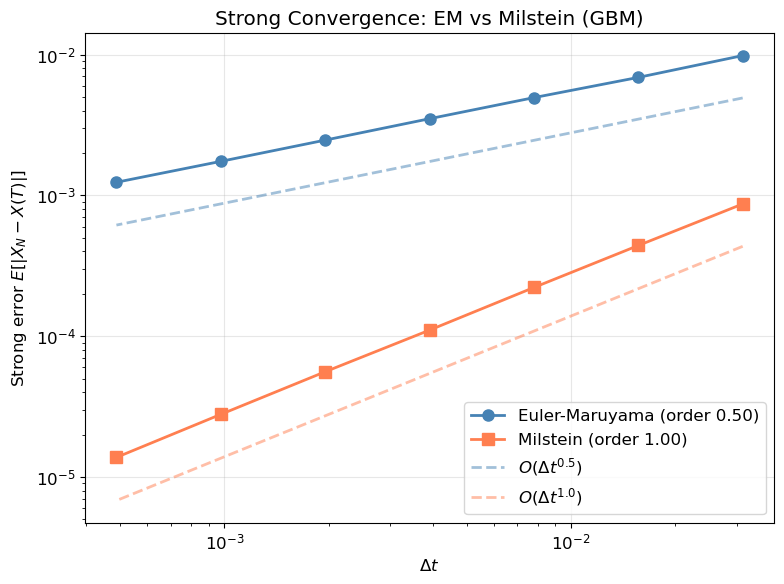

In [15]:
# =============================================================================
# Verification: Convergence Orders
# =============================================================================

em_pass = 'PASS' if np.abs(em_order - 0.5) < TOL_CONVERGENCE else 'FAIL'
mil_pass = 'PASS' if np.abs(mil_order - 1.0) < TOL_CONVERGENCE else 'FAIL'

print(f"EM convergence order: max relative error = {np.abs(em_order - 0.5):.2e} [{em_pass}]")
print(f"  Estimated order = {em_order:.3f} (expected 0.5)")
print(f"Milstein convergence order: max relative error = {np.abs(mil_order - 1.0):.2e} [{mil_pass}]")
print(f"  Estimated order = {mil_order:.3f} (expected 1.0)")

# Log-log convergence plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(dt_arr, em_err, 'o-', color=C_PRIMARY, markersize=8, label=f'Euler-Maruyama (order {em_order:.2f})')
ax.loglog(dt_arr, mil_err, 's-', color=C_SECONDARY, markersize=8, label=f'Milstein (order {mil_order:.2f})')

# Reference slopes
ref_dt = np.array([dt_arr[0], dt_arr[-1]])
ax.loglog(ref_dt, 0.5 * em_err[0] * (ref_dt / ref_dt[0])**0.5,
          '--', color=C_PRIMARY, alpha=0.5, label='$O(\\Delta t^{0.5})$')
ax.loglog(ref_dt, 0.5 * mil_err[0] * (ref_dt / ref_dt[0])**1.0,
          '--', color=C_SECONDARY, alpha=0.5, label='$O(\\Delta t^{1.0})$')

ax.set_xlabel('$\\Delta t$')
ax.set_ylabel('Strong error $E[|X_N - X(T)|]$')
ax.set_title('Strong Convergence: EM vs Milstein (GBM)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Fokker-Planck Equation

### From SDE to PDE

If $X_t$ solves $dX = f(X)\,dt + g(X)\,dW$, then its probability density $p(x, t)$ satisfies the **Fokker-Planck (forward Kolmogorov) equation**:

$$\boxed{\frac{\partial p}{\partial t} = -\frac{\partial}{\partial x}\bigl[f(x)\,p\bigr] + \frac{1}{2}\frac{\partial^2}{\partial x^2}\bigl[g(x)^2\,p\bigr]}$$

### Steady State for OU Process

For $dX = \theta(\mu - X)\,dt + \sigma\,dW$, the steady-state density is:

$$p_{\infty}(x) = \mathcal{N}\left(\mu, \frac{\sigma^2}{2\theta}\right)$$

In [16]:
# =============================================================================
# Section 7: Fokker-Planck Equation Solver
# =============================================================================

def fokker_planck_solve(f_drift, g_diff, x_grid, t_final, n_time_steps,
                        p0, method='crank-nicolson'):
    """Solve the Fokker-Planck equation using finite differences.

    Solves dp/dt = -d/dx[f*p] + 0.5*d^2/dx^2[g^2*p]
    using the Crank-Nicolson (implicit trapezoidal) scheme.

    Args:
        f_drift: Drift function evaluated on x_grid.  Shape: (n_x,)
        g_diff: Diffusion function evaluated on x_grid.  Shape: (n_x,)
        x_grid: Spatial grid.  Shape: (n_x,)
        t_final: Final time.
        n_time_steps: Number of time steps.
        p0: Initial density.  Shape: (n_x,)
        method: 'crank-nicolson' or 'implicit'.

    Returns:
        p_history: Density at saved time steps.  Shape: (n_save, n_x)
        t_save: Saved time values.  Shape: (n_save,)
    """
    n_x = len(x_grid)
    dx = x_grid[1] - x_grid[0]
    dt = t_final / n_time_steps

    # Diffusion coefficient D(x) = 0.5 * g(x)^2
    D = 0.5 * g_diff**2

    # Build the spatial operator L such that dp/dt = L @ p
    # Using central differences for advection and diffusion
    # Advection: -d/dx[f*p] using upwind-corrected central differences
    # Diffusion: d^2/dx^2[D*p] using second-order central differences

    # For Crank-Nicolson: (I - 0.5*dt*L) p^{n+1} = (I + 0.5*dt*L) p^n

    # Construct tridiagonal operator L
    # L_ij: sub-diagonal, diagonal, super-diagonal
    sub = np.zeros(n_x)
    main = np.zeros(n_x)
    sup = np.zeros(n_x)

    for i in range(1, n_x - 1):
        # Diffusion part: d^2/dx^2 [D*p]
        # approx (D_{i+1}*p_{i+1} - 2*D_i*p_i + D_{i-1}*p_{i-1}) / dx^2
        sub[i] = D[i-1] / dx**2
        main[i] = -2 * D[i] / dx**2
        sup[i] = D[i+1] / dx**2

        # Advection part: -d/dx[f*p]
        # approx -(f_{i+1}*p_{i+1} - f_{i-1}*p_{i-1}) / (2*dx)
        sub[i] += f_drift[i-1] / (2 * dx)
        sup[i] += -f_drift[i+1] / (2 * dx)

    # Absorbing boundary conditions (p = 0 at boundaries)
    main[0] = -1.0 / dt   # Forces p -> 0 at boundary
    main[-1] = -1.0 / dt

    L = diags([sub[1:], main, sup[:-1]], [-1, 0, 1], format='csc')
    I_mat = diags([np.ones(n_x)], [0], format='csc')

    if method == 'crank-nicolson':
        A = I_mat - 0.5 * dt * L
        B = I_mat + 0.5 * dt * L
    else:  # fully implicit
        A = I_mat - dt * L
        B = I_mat

    # Time stepping
    n_save = min(100, n_time_steps)
    save_every = max(1, n_time_steps // n_save)
    p = p0.copy()
    p_history = [p.copy()]
    t_save = [0.0]

    for n in range(1, n_time_steps + 1):
        rhs = B @ p
        p = spsolve(A, rhs)
        p = np.maximum(p, 0)  # Enforce non-negativity

        if n % save_every == 0 or n == n_time_steps:
            p_history.append(p.copy())
            t_save.append(n * dt)

    return np.array(p_history), np.array(t_save)

In [17]:
# Solve Fokker-Planck for the OU process
# dX = theta*(mu - X) dt + sigma dW

# Spatial grid
X_MIN, X_MAX = -3.0, 5.0
N_X = 500
x_fp = np.linspace(X_MIN, X_MAX, N_X)
dx_fp = x_fp[1] - x_fp[0]

# Drift and diffusion on grid
f_ou_grid = OU_THETA * (OU_MU - x_fp)
g_ou_grid = OU_SIGMA * np.ones(N_X)

# Initial condition: delta-like Gaussian centered at OU_X0
p0_fp = stats.norm.pdf(x_fp, OU_X0, 0.05)
p0_fp /= np.trapz(p0_fp, x_fp)  # Normalize

# Solve
T_FP = 3.0
N_T_FP = 5000
p_hist, t_fp_save = fokker_planck_solve(
    f_ou_grid, g_ou_grid, x_fp, T_FP, N_T_FP, p0_fp
)

AttributeError: module 'numpy' has no attribute 'trapz'

In [ ]:
# Verification: FPE density integrates to 1
final_integral = np.trapz(p_hist[-1], x_fp)
rel_err_integral = np.abs(final_integral - 1.0)
status_integral = 'PASS' if rel_err_integral < 0.05 else 'FAIL'
print(f"FPE density integral: max relative error = {rel_err_integral:.2e} [{status_integral}]")
print(f"  int p(x, T) dx = {final_integral:.6f}")

# Compare FPE solution with EM histogram at final time
np.random.seed(SEED)
n_fpe_paths = 50000
n_fpe_steps = 5000
dt_fpe = T_FP / n_fpe_steps
X_fpe_mc = np.zeros((n_fpe_paths, n_fpe_steps + 1))
X_fpe_mc[:, 0] = OU_X0
for k in range(n_fpe_steps):
    dW_k = np.sqrt(dt_fpe) * np.random.randn(n_fpe_paths)
    X_fpe_mc[:, k+1] = (X_fpe_mc[:, k]
                         + OU_THETA * (OU_MU - X_fpe_mc[:, k]) * dt_fpe
                         + OU_SIGMA * dW_k)

# Steady-state analytical density
ou_ss_var = OU_SIGMA**2 / (2 * OU_THETA)
p_ss_analytical = stats.norm.pdf(x_fp, OU_MU, np.sqrt(ou_ss_var))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: FPE vs MC histogram at final time
axes[0].hist(X_fpe_mc[:, -1], bins=80, density=True, alpha=0.5,
             color=C_PRIMARY, label='EM histogram')
axes[0].plot(x_fp, p_hist[-1], color=C_SECONDARY, linewidth=2,
             label='FPE solution')
axes[0].plot(x_fp, p_ss_analytical, '--', color=C_TERTIARY, linewidth=2,
             label='Steady-state $\mathcal{N}(\mu, \sigma^2/2\\theta)$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('Density')
axes[0].set_title(f'FPE vs Monte Carlo at $T = {T_FP}$')
axes[0].legend()
axes[0].set_xlim(X_MIN, X_MAX)

# Panel 2: Density evolution
n_snapshots = min(8, len(t_fp_save))
cmap = plt.cm.get_cmap(C_EVOLUTION, n_snapshots)
snapshot_indices = np.linspace(0, len(t_fp_save) - 1, n_snapshots, dtype=int)
for idx, si in enumerate(snapshot_indices):
    axes[1].plot(x_fp, p_hist[si], color=cmap(idx),
                label=f'$t = {t_fp_save[si]:.2f}$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$p(x, t)$')
axes[1].set_title('Fokker-Planck Density Evolution (OU Process)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim(X_MIN, X_MAX)

plt.tight_layout()
plt.show()

---
## 8. Application: Noisy Robot Dynamics

### Stochastic Unicycle Model

A unicycle robot with process noise:

$$\begin{cases}
dx = v\cos\theta\,dt + \sigma_v \cos\theta\,dW_1 \\
dy = v\sin\theta\,dt + \sigma_v \sin\theta\,dW_2 \\
d\theta = \omega\,dt + \sigma_\omega\,dW_3
\end{cases}$$

where $W_1, W_2, W_3$ are independent Brownian motions.

In [ ]:
# =============================================================================
# Section 8: Noisy Robot Dynamics
# =============================================================================

def noisy_unicycle_sde(v, omega, sigma_v, sigma_omega, x0, y0, theta0,
                       t_final, n_steps, n_paths=1, seed=None):
    """Simulate noisy unicycle robot dynamics.

    Solves the stochastic unicycle equations using Euler-Maruyama.

    Args:
        v: Nominal forward velocity.
        omega: Nominal angular velocity.
        sigma_v: Velocity noise intensity.
        sigma_omega: Angular velocity noise intensity.
        x0: Initial x position.
        y0: Initial y position.
        theta0: Initial heading angle (radians).
        t_final: Final time.
        n_steps: Number of time steps.
        n_paths: Number of sample paths.
        seed: Random seed.

    Returns:
        t: Time grid.  Shape: (n_steps + 1,)
        X: x positions.  Shape: (n_paths, n_steps + 1)
        Y: y positions.  Shape: (n_paths, n_steps + 1)
        Theta: heading angles.  Shape: (n_paths, n_steps + 1)
    """
    if seed is not None:
        np.random.seed(seed)

    dt = t_final / n_steps
    sqrt_dt = np.sqrt(dt)
    t = np.linspace(0, t_final, n_steps + 1)

    X = np.zeros((n_paths, n_steps + 1))
    Y = np.zeros((n_paths, n_steps + 1))
    Theta = np.zeros((n_paths, n_steps + 1))

    X[:, 0] = x0
    Y[:, 0] = y0
    Theta[:, 0] = theta0

    for k in range(n_steps):
        dW1 = sqrt_dt * np.random.randn(n_paths)
        dW2 = sqrt_dt * np.random.randn(n_paths)
        dW3 = sqrt_dt * np.random.randn(n_paths)

        cos_th = np.cos(Theta[:, k])
        sin_th = np.sin(Theta[:, k])

        X[:, k+1] = X[:, k] + v * cos_th * dt + sigma_v * cos_th * dW1
        Y[:, k+1] = Y[:, k] + v * sin_th * dt + sigma_v * sin_th * dW2
        Theta[:, k+1] = Theta[:, k] + omega * dt + sigma_omega * dW3

    return t, X, Y, Theta

In [ ]:
# Simulate noisy robot ensemble
N_ROBOT_PATHS = 500
N_ROBOT_STEPS = 2000
T_ROBOT = 10.0

t_robot, X_robot, Y_robot, Theta_robot = noisy_unicycle_sde(
    ROBOT_V, ROBOT_OMEGA, ROBOT_SIGMA_V, ROBOT_SIGMA_OMEGA,
    x0=0.0, y0=0.0, theta0=0.0,
    t_final=T_ROBOT, n_steps=N_ROBOT_STEPS,
    n_paths=N_ROBOT_PATHS, seed=SEED
)


def covariance_ellipse(mean_x, mean_y, cov, n_std=2.0, n_points=100):
    """Compute points on a covariance ellipse.

    Args:
        mean_x: Center x coordinate.
        mean_y: Center y coordinate.
        cov: 2x2 covariance matrix.  Shape: (2, 2)
        n_std: Number of standard deviations for ellipse radius.
        n_points: Number of points on the ellipse.

    Returns:
        ellipse_x: x coordinates of ellipse.  Shape: (n_points,)
        ellipse_y: y coordinates of ellipse.  Shape: (n_points,)
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = np.maximum(eigenvalues, 0)  # Numerical safety
    angle = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])

    theta_pts = np.linspace(0, 2 * np.pi, n_points)
    a = n_std * np.sqrt(eigenvalues[0])
    b = n_std * np.sqrt(eigenvalues[1])

    ellipse_x = (mean_x + a * np.cos(theta_pts) * np.cos(angle)
                 - b * np.sin(theta_pts) * np.sin(angle))
    ellipse_y = (mean_y + a * np.cos(theta_pts) * np.sin(angle)
                 + b * np.sin(theta_pts) * np.cos(angle))
    return ellipse_x, ellipse_y


# Plot robot ensemble with covariance ellipses
fig, ax = plt.subplots(figsize=(10, 10))

# Plot sample paths (subset)
for i in range(min(50, N_ROBOT_PATHS)):
    ax.plot(X_robot[i], Y_robot[i], alpha=0.15, color=C_PRIMARY, linewidth=0.5)

# Deterministic path (no noise)
t_det, X_det, Y_det, _ = noisy_unicycle_sde(
    ROBOT_V, ROBOT_OMEGA, 0.0, 0.0,
    x0=0.0, y0=0.0, theta0=0.0,
    t_final=T_ROBOT, n_steps=N_ROBOT_STEPS, n_paths=1, seed=SEED
)
ax.plot(X_det[0], Y_det[0], 'k-', linewidth=2, label='Deterministic path')

# Covariance ellipses at time snapshots
snapshot_times = [1.0, 3.0, 5.0, 7.0, 9.0]
colors_snap = [plt.cm.get_cmap('Reds')(0.3 + 0.7 * i / len(snapshot_times))
               for i in range(len(snapshot_times))]

for idx, t_snap in enumerate(snapshot_times):
    k = int(t_snap / T_ROBOT * N_ROBOT_STEPS)
    mx = np.mean(X_robot[:, k])
    my = np.mean(Y_robot[:, k])
    cov_xy = np.cov(X_robot[:, k], Y_robot[:, k])
    ex, ey = covariance_ellipse(mx, my, cov_xy, n_std=2.0)
    ax.plot(ex, ey, color=colors_snap[idx], linewidth=2,
            label=f'$2\\sigma$ ellipse, $t={t_snap}$')
    ax.plot(mx, my, 'o', color=colors_snap[idx], markersize=6)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Noisy Unicycle Robot: Ensemble Simulation')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Comprehensive Visualizations

This section collects the key visualizations into publication-quality multi-panel figures.

In [ ]:
# =============================================================================
# Section 9: Comprehensive Visualization Panel
# =============================================================================

# --- Figure 1: Brownian Motion Properties ---
np.random.seed(SEED)
t_vis, W_vis = brownian_motion(T_FINAL, N_STEPS, n_paths=5)
qv_vis = quadratic_variation(W_vis, t_vis)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) Sample paths
for i in range(5):
    axes[0, 0].plot(t_vis, W_vis[i], alpha=0.8)
axes[0, 0].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[0, 0].set_xlabel('Time $t$')
axes[0, 0].set_ylabel('$W_t$')
axes[0, 0].set_title('(a) Brownian Motion Sample Paths')

# (0,1) Quadratic variation
for i in range(5):
    axes[0, 1].plot(t_vis, qv_vis[i], alpha=0.6)
axes[0, 1].plot(t_vis, t_vis, 'k--', linewidth=2, label='$[W]_t = t$')
axes[0, 1].set_xlabel('Time $t$')
axes[0, 1].set_ylabel('$[W]_t$')
axes[0, 1].set_title('(b) Quadratic Variation')
axes[0, 1].legend()

# (1,0) Ito vs Stratonovich comparison
np.random.seed(123)
n_compare = 10000
n_steps_compare = 1000
dt_c = T_FINAL / n_steps_compare
dW_c = np.sqrt(dt_c) * np.random.randn(n_compare, n_steps_compare)
W_c = np.zeros((n_compare, n_steps_compare + 1))
W_c[:, 1:] = np.cumsum(dW_c, axis=1)

ito_vals = np.sum(W_c[:, :-1] * dW_c, axis=1)
strat_vals = np.sum(0.5 * (W_c[:, :-1] + W_c[:, 1:]) * dW_c, axis=1)

axes[1, 0].hist(ito_vals, bins=60, density=True, alpha=0.6,
                color=C_PRIMARY, label=f'It\^o: $E = {np.mean(ito_vals):.3f}$')
axes[1, 0].hist(strat_vals, bins=60, density=True, alpha=0.6,
                color=C_SECONDARY, label=f'Strat: $E = {np.mean(strat_vals):.3f}$')
axes[1, 0].set_xlabel('$\\int W\\,dW$')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('(c) It\^o vs Stratonovich: $\\int W\\,dW$')
axes[1, 0].legend()

# (1,1) EM vs Milstein convergence (log-log)
axes[1, 1].loglog(dt_arr, em_err, 'o-', color=C_PRIMARY, markersize=8,
                  label=f'EM (order {em_order:.2f})')
axes[1, 1].loglog(dt_arr, mil_err, 's-', color=C_SECONDARY, markersize=8,
                  label=f'Milstein (order {mil_order:.2f})')
ref_dt = np.array([dt_arr[0], dt_arr[-1]])
axes[1, 1].loglog(ref_dt, 0.5 * em_err[0] * (ref_dt / ref_dt[0])**0.5,
                  '--', color=C_PRIMARY, alpha=0.4)
axes[1, 1].loglog(ref_dt, 0.5 * mil_err[0] * (ref_dt / ref_dt[0])**1.0,
                  '--', color=C_SECONDARY, alpha=0.4)
axes[1, 1].set_xlabel('$\\Delta t$')
axes[1, 1].set_ylabel('Strong error')
axes[1, 1].set_title('(d) Strong Convergence (GBM)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Figure 2: Fokker-Planck Evolution & Robot Ensemble ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: FPE density evolution (3D-like using filled regions)
n_show = min(10, len(t_fp_save))
show_idx = np.linspace(0, len(t_fp_save) - 1, n_show, dtype=int)
cmap_fp = plt.cm.get_cmap(C_EVOLUTION, n_show)

for idx, si in enumerate(show_idx):
    offset = idx * 0.15
    axes[0].fill_between(x_fp, offset, p_hist[si] + offset,
                         alpha=0.4, color=cmap_fp(idx))
    axes[0].plot(x_fp, p_hist[si] + offset, color=cmap_fp(idx), linewidth=1)

axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$p(x, t)$ + offset')
axes[0].set_title('Fokker-Planck Density Evolution (OU)')
axes[0].set_xlim(X_MIN, X_MAX)

# Add colorbar-like annotation
sm = plt.cm.ScalarMappable(cmap=plt.cm.get_cmap(C_EVOLUTION),
                           norm=plt.Normalize(vmin=0, vmax=T_FP))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[0], label='Time $t$', pad=0.02)

# Panel 2: Robot ensemble (compact version)
for i in range(min(30, N_ROBOT_PATHS)):
    axes[1].plot(X_robot[i], Y_robot[i], alpha=0.12, color=C_PRIMARY, linewidth=0.5)
axes[1].plot(X_det[0], Y_det[0], 'k-', linewidth=2, label='Deterministic')

for idx, t_snap in enumerate([2.0, 5.0, 8.0]):
    k = int(t_snap / T_ROBOT * N_ROBOT_STEPS)
    mx = np.mean(X_robot[:, k])
    my = np.mean(Y_robot[:, k])
    cov_xy = np.cov(X_robot[:, k], Y_robot[:, k])
    ex, ey = covariance_ellipse(mx, my, cov_xy, n_std=2.0)
    color_e = plt.cm.Reds(0.4 + 0.2 * idx)
    axes[1].plot(ex, ey, color=color_e, linewidth=2,
                label=f'$2\\sigma$, $t={t_snap}$')
    axes[1].plot(mx, my, 'o', color=color_e, markersize=5)

axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')
axes[1].set_title('Noisy Unicycle: Ensemble + Covariance')
axes[1].set_aspect('equal')
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. Extensions & Further Topics

### 10.1 Stratonovich Calculus

The **Stratonovich integral** uses midpoint evaluation:

$$\int_0^T f \circ dW = \lim \sum f\!\left(\frac{t_k + t_{k+1}}{2}\right) \Delta W_k$$

The Stratonovich chain rule is the **standard** chain rule (no correction term), which is why physicists often prefer it. The It\^o-Stratonovich conversion:

$$f \circ dW = f\,dW + \frac{1}{2}g\,f'\,dt$$

### 10.2 Stochastic Stability (Lyapunov)

For $dX = f(X)\,dt + g(X)\,dW$, a Lyapunov function $V(x)$ satisfies:

$$\mathcal{L}V(x) = f(x) V'(x) + \frac{1}{2}g(x)^2 V''(x) \leq -\alpha V(x)$$

where $\mathcal{L}$ is the **infinitesimal generator**. This gives exponential stability in mean square.

### 10.3 Stochastic Optimal Control

Minimize $J = E\left[\int_0^T L(X_t, u_t)\,dt + \Phi(X_T)\right]$ subject to $dX = f(X, u)\,dt + g(X)\,dW$.

The **Hamilton-Jacobi-Bellman (HJB) equation**:

$$-\frac{\partial V}{\partial t} = \min_u \left[L + f V_x + \frac{1}{2}g^2 V_{xx}\right]$$

### 10.4 Feynman-Kac Formula

Connects SDEs to PDEs. If $u(x, t)$ solves:

$$\frac{\partial u}{\partial t} + \mu \frac{\partial u}{\partial x} + \frac{1}{2}\sigma^2 \frac{\partial^2 u}{\partial x^2} - r\,u = 0, \quad u(x, T) = \phi(x)$$

then:

$$\boxed{u(x, t) = E\left[e^{-r(T-t)} \phi(X_T) \,\big|\, X_t = x\right]}$$

### 10.5 SDE-GP Correspondence

A linear time-invariant SDE:

$$dX = A\,X\,dt + L\,dW$$

defines a **Gaussian Process** with stationary kernel:

$$k(\tau) = \Sigma_{\infty} e^{A|\tau|}$$

where $\Sigma_{\infty}$ solves the continuous Lyapunov equation $A\Sigma + \Sigma A^T + LL^T = 0$.

This correspondence is the basis of **state-space methods** for scalable GP regression (Hartikainen & Sarkka, 2010), reducing $O(N^3)$ to $O(N)$ via Kalman filtering.

---

### Summary of Key Results

| Concept | Key Formula |
|---------|-------------|
| Brownian motion | $E[W_t] = 0$, $E[W_t^2] = t$, $[W]_t = t$ |
| It\^o isometry | $E[(\int f\,dW)^2] = E[\int f^2\,dt]$ |
| It\^o's lemma | $df = (f_t + \mu f_x + \tfrac{1}{2}\sigma^2 f_{xx})dt + \sigma f_x\,dW$ |
| Euler-Maruyama | $X_{k+1} = X_k + f\Delta t + g\Delta W$, order 0.5 |
| Milstein | Adds $\tfrac{1}{2}gg'(\Delta W^2 - \Delta t)$, order 1.0 |
| Fokker-Planck | $\partial_t p = -\partial_x(fp) + \tfrac{1}{2}\partial_{xx}(g^2 p)$ |